# 03b Tree-Based Time Series Models (Random Forest & XGBoost)

> Objective: Build a leakage-safe, tree-based forecasting pipeline for quarterly Credit Reporting complaints using the same data split/evaluation framing as 03a. This notebook starts with feature engineering + Random Forest multi-horizon direct forecasting.

In [1]:
# ============================================================================
# IMPORT STATEMENTS
# ============================================================================
# Core libraries for data prep, feature engineering, modeling, and diagnostics.

import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Compatibility guard for environments with optional pyarrow/sklearn binary mismatch.
os.environ.setdefault("SKLEARN_ALLOW_INVALID_PYARROW", "1")

SKLEARN_AVAILABLE = True
try:
    from sklearn.preprocessing import StandardScaler
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.multioutput import MultiOutputRegressor
except Exception as e:
    SKLEARN_AVAILABLE = False
    print("scikit-learn import unavailable in this kernel:", e)

# XGBoost imported for upcoming section extension.
import xgboost as xgb

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

warnings.filterwarnings("ignore")

In [2]:
# ============================================================================
# DATA SETUP + SHARED HELPERS (MATCH 03a SPLIT/EVAL STYLE)
# ============================================================================
# Load Credit card target series and enforce same split logic.

FREQ_ALIAS = "Q"
SEASONAL_PERIODS = 4
FORECAST_HORIZON = 4
OUTPUT_TAG = "03b_creditcard_quarterly"

cols = ["Product", "Date received"]
df = pd.read_parquet("../data/processed/credit_card_dataset.parquet", columns=cols)
df["Date received"] = pd.to_datetime(df["Date received"], errors="coerce")
df = df.dropna(subset=["Date received", "Product"])
mask_cc = df["Product"].str.lower().str.startswith("credit card", na=False)
df_creditcard = df.loc[mask_cc].copy()

df_creditcard = df_creditcard.loc[
    (df_creditcard["Date received"] >= "2012-01-01") &
    (df_creditcard["Date received"] <= "2025-12-31")
].copy()

df_creditcard["period"] = df_creditcard["Date received"].dt.to_period(FREQ_ALIAS)
series_df = (
    df_creditcard.groupby("period")
      .size()
      .rename("y")
      .to_frame()
      .sort_index()
)
y = series_df["y"].astype(float)

n = len(y)
test_size = max(4, n // 5)
val_size = test_size
while n - (val_size + test_size) < 8 and test_size > 2:
    test_size -= 1
    val_size = test_size

train = y.iloc[: n - val_size - test_size].copy()
val   = y.iloc[n - val_size - test_size : n - test_size].copy()
test  = y.iloc[n - test_size :].copy()

print(f"Frequency: {FREQ_ALIAS} | Train={len(train)}, Val={len(val)}, Test={len(test)}")
display(series_df.head())


Frequency: Q | Train=34, Val=11, Test=11


,y
period,
2012Q1,3728
2012Q2,4195
2012Q3,3698
2012Q4,3445
2013Q1,3534


In [3]:
# Shared metrics + result/plot helpers for standalone execution
def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.abs(y_true) + np.abs(y_pred)
    ratio = np.where(denom == 0, 0.0, 2.0 * np.abs(y_true - y_pred) / denom)
    return float(100.0 * np.mean(ratio))

def mae(y_true, y_pred):
    return float(np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred))))

def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((np.asarray(y_true) - np.asarray(y_pred)) ** 2)))

eval_rows = []

def append_result(model_name, val_pred, test_pred, runtime_sec):
    vp = np.asarray(val_pred, dtype=float)
    tp = np.asarray(test_pred, dtype=float)
    yt_v = y_val_multi.iloc[:, 0].values
    yt_t = y_test_multi.iloc[:, 0].values
    eval_rows.append({
        "Model": model_name,
        "sMAPE_val": smape(yt_v, vp[:, 0] if vp.ndim > 1 else vp),
        "sMAPE_test": smape(yt_t, tp[:, 0] if tp.ndim > 1 else tp),
        "MAE_val": mae(yt_v, vp[:, 0] if vp.ndim > 1 else vp),
        "MAE_test": mae(yt_t, tp[:, 0] if tp.ndim > 1 else tp),
        "RMSE_val": rmse(yt_v, vp[:, 0] if vp.ndim > 1 else vp),
        "RMSE_test": rmse(yt_t, tp[:, 0] if tp.ndim > 1 else tp),
        "runtime_sec": float(runtime_sec),
    })

def plot_section_predictions(title, pred_map):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
    for name, (vp, tp) in pred_map.items():
        v = vp[:, 0] if np.asarray(vp).ndim > 1 else np.asarray(vp)
        t = tp[:, 0] if np.asarray(tp).ndim > 1 else np.asarray(tp)
        axes[0].plot(y_val_multi.index.astype(str), y_val_multi.iloc[:, 0].values, label="Actual", color="black")
        axes[0].plot(y_val_multi.index.astype(str), v, label=name)
        axes[1].plot(y_test_multi.index.astype(str), y_test_multi.iloc[:, 0].values, label="Actual", color="black")
        axes[1].plot(y_test_multi.index.astype(str), t, label=name)
    axes[0].set_title(f"{title} - Validation")
    axes[1].set_title(f"{title} - Test")
    for ax in axes:
        ax.tick_params(axis="x", rotation=45)
        ax.grid(True, alpha=0.3)
        ax.legend()
    plt.tight_layout()
    plt.show()


## 1. Feature Engineering + Leakage-Proof Pipeline

We build a direct multi-horizon forecasting design with strict leakage control.

- Targets: y_h1 to y_h4 are shifted targets (t+1...t+4)
- Features: lags, rolling stats, seasonal rolling, EWMA, calendar, trend/cycle Fourier terms
- Leakage controls:
  - features at time t only use data available by t
  - target columns are shifted forward
  - scaling is fit on train only, then applied to val/test
  - all splits are time-ordered and aligned to the multi-horizon frame

Feature matrix shape: (40, 32)
Target matrix shape: (40, 4)
Split shapes:
  X_train: (30, 32) | y_train_multi: (30, 4)
  X_val: (4, 32) | y_val_multi: (4, 4)
  X_test: (6, 32) | y_test_multi: (6, 4)


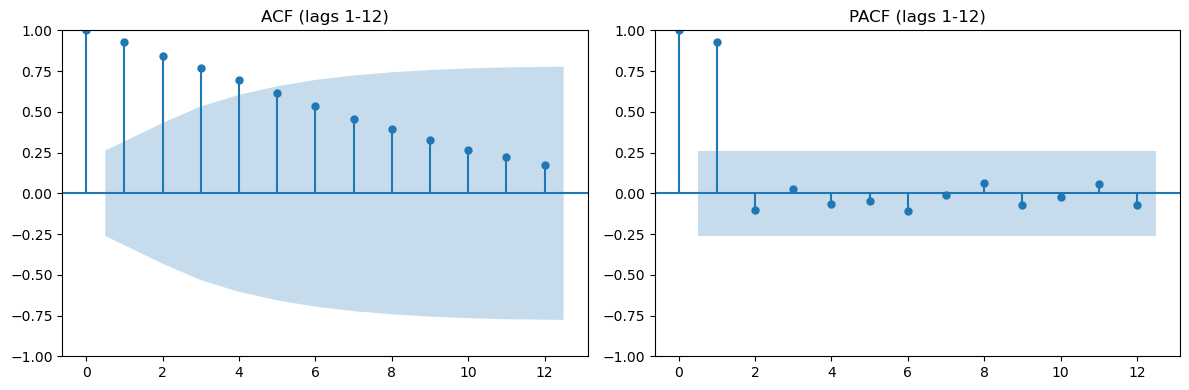

In [4]:
# ============================================================================
# SECTION 1: FEATURE ENGINEERING + LEAKAGE-PROOF PREP
# ============================================================================
# Direct multi-horizon targets and leakage-safe feature matrix construction.

# ---- Multi-horizon direct targets (h=1..4) ----
y1 = y.shift(-1)
y2 = y.shift(-2)
y3 = y.shift(-3)
y4 = y.shift(-4)
y_multi = pd.concat([y1, y2, y3, y4], axis=1)
y_multi.columns = ["y_h1", "y_h2", "y_h3", "y_h4"]

# ---- Feature block on full y (no future leak) ----
feat = pd.DataFrame(index=y.index)

# Lags: y(t-1) ... y(t-12)
for l in range(1, 13):
    feat[f"lag_{l}"] = y.shift(l)

# Rolling windows: local (4q) and annual-like (12q)
feat["roll_mean_4"] = y.rolling(4).mean()
feat["roll_std_4"] = y.rolling(4).std()
feat["roll_mean_12"] = y.rolling(12).mean()
feat["roll_std_12"] = y.rolling(12).std()

# Seasonal rolling proxy (window=4 over quarterly cadence)
feat["seasonal_roll_mean_4"] = y.rolling(4).mean()
feat["seasonal_roll_std_4"] = y.rolling(4).std()

# EWMA with alpha=0.3
feat["ewm_a03"] = y.ewm(alpha=0.3, adjust=False).mean()

# Calendar / trend features
feat["cum_q"] = np.arange(len(y), dtype=float)
feat["year_since_2012"] = (y.index.year - 2012).astype(float)
feat["days_since_start"] = (y.index.to_timestamp(how="end") - y.index[0].to_timestamp(how="end")).days.astype(float)

# Quarter dummies (Q1..Q4)
q_dummies = pd.get_dummies(y.index.quarter, prefix="Q", drop_first=False).astype(int)
q_dummies.index = y.index
feat = pd.concat([feat, q_dummies], axis=1)

# Fourier terms for quarterly period=SEASONAL_PERIODS, k=1,2
for k in [1, 2]:
    feat[f"sin_k{k}"] = np.sin(2 * np.pi * k * feat["cum_q"] / 4.0)
    feat[f"cos_k{k}"] = np.cos(2 * np.pi * k * feat["cum_q"] / 4.0)

# Linear trend residual feature (deterministic transform)
coef = np.polyfit(feat["cum_q"].values, y.values, 1)
trend_line = coef[0] * feat["cum_q"].values + coef[1]
feat["trend_linear"] = trend_line
feat["trend_resid"] = y.values - trend_line

# Align X and y_multi, dropping rows with any NA from lag/rolling/target shifts
frame = pd.concat([feat, y_multi], axis=1).dropna().copy()

X = frame[feat.columns]
Y = frame[y_multi.columns]

# Required split alignment (per request), using train length from 03a split
# X_train = X[:len(train)-4], X_val = X[len(train)-4:len(train)], X_test = X[len(train):]
split_train_end = len(train) - 4
split_val_end = len(train)

X_train = X.iloc[:split_train_end].copy()
X_val = X.iloc[split_train_end:split_val_end].copy()
X_test = X.iloc[split_val_end:].copy()

y_train_multi = Y.iloc[:split_train_end].copy()
y_val_multi = Y.iloc[split_train_end:split_val_end].copy()
y_test_multi = Y.iloc[split_val_end:].copy()

# Scale on train only to avoid leakage, then transform val/test.
# If sklearn is unavailable in the current kernel, use unscaled features (trees are scale-invariant).
sk_ok = globals().get("SKLEARN_AVAILABLE", False)
if sk_ok:
    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), index=X_train.index, columns=X_train.columns)
    X_val_scaled = pd.DataFrame(scaler.transform(X_val), index=X_val.index, columns=X_val.columns)
    X_test_scaled = pd.DataFrame(scaler.transform(X_test), index=X_test.index, columns=X_test.columns)
else:
    X_train_scaled = X_train.copy()
    X_val_scaled = X_val.copy()
    X_test_scaled = X_test.copy()

print("Feature matrix shape:", X.shape)
print("Target matrix shape:", Y.shape)
print("Split shapes:")
print("  X_train:", X_train_scaled.shape, "| y_train_multi:", y_train_multi.shape)
print("  X_val:", X_val_scaled.shape, "| y_val_multi:", y_val_multi.shape)
print("  X_test:", X_test_scaled.shape, "| y_test_multi:", y_test_multi.shape)

# ACF/PACF diagnostics up to lag 12 for seasonality/trend structure check
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(y.values, lags=12, ax=axes[0])
axes[0].set_title("ACF (lags 1-12)")
plot_pacf(y.values, lags=12, ax=axes[1], method="ywm")
axes[1].set_title("PACF (lags 1-12)")
plt.tight_layout()
plt.show()

## 2. Random Forest (Multi-Horizon Direct)

We fit a multi-output Random Forest to predict y_h1..y_h4 simultaneously from the engineered features.

- Model: MultiOutputRegressor(RandomForestRegressor)
- Hyperparameters: n_estimators=500, max_depth=6, random_state=42
- Evaluation:
  - macro-averaged validation/test metrics via append_result
  - per-horizon sMAPE table (h=1..4)
  - horizon-1 visualization for val/test trajectory checking
- Leakage guardrails remain unchanged from Section 1

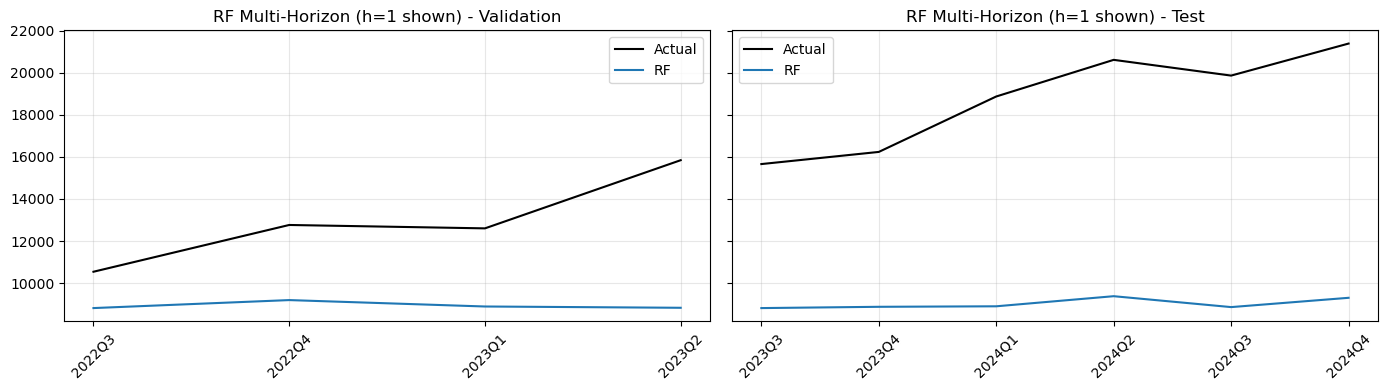

Model Summary


,Model,sMAPE_val,sMAPE_test,MAE_val,MAE_test,RMSE_val,RMSE_test,runtime_sec
0,RF-Multi,35.431,69.42,4005.134,9746.942,4434.992,9944.996,2.811


Per-Horizon Metrics


,Horizon,sMAPE_val,sMAPE_test,MAE_val,MAE_test,RMSE_val,RMSE_test
0,h=1,35.431,69.420,4005.134,9746.942,4434.992,9944.996
1,h=2,37.362,66.874,4541.646,9956.993,4771.947,10128.517
2,h=3,28.934,60.372,3876.549,9833.956,4142.033,9977.817
3,h=4,34.069,59.063,4887.519,9937.792,5061.784,10043.707


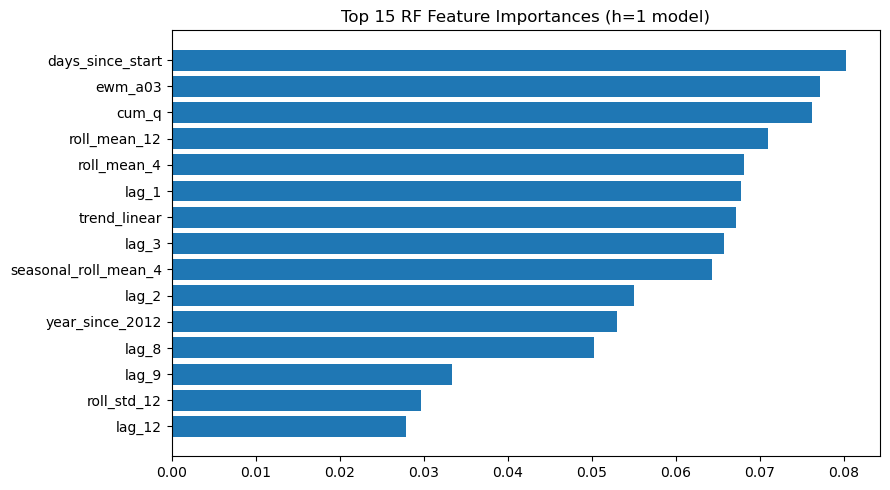

Random Forest multi-horizon evaluation complete.


In [5]:
# ============================================================================
# SECTION 2: RANDOM FOREST (MULTI-OUTPUT, DIRECT HORIZONS)
# ============================================================================

t0 = time.perf_counter()
rf = MultiOutputRegressor(
    RandomForestRegressor(
        n_estimators=500,
        max_depth=6,
        random_state=42,
        n_jobs=-1
    )
)
rf.fit(X_train_scaled, y_train_multi)
runtime = time.perf_counter() - t0

val_pred = rf.predict(X_val_scaled)
test_pred = rf.predict(X_test_scaled)

append_result("RF-Multi", val_pred, test_pred, runtime)
plot_section_predictions("RF Multi-Horizon (h=1 shown)", {"RF": (val_pred, test_pred)})

# Per-horizon sMAPE/MAE/RMSE table
h_rows = []
for h in range(4):
    h_rows.append({
        "Horizon": f"h={h+1}",
        "sMAPE_val": smape(y_val_multi.iloc[:, h].values, val_pred[:, h]),
        "sMAPE_test": smape(y_test_multi.iloc[:, h].values, test_pred[:, h]),
        "MAE_val": mae(y_val_multi.iloc[:, h].values, val_pred[:, h]),
        "MAE_test": mae(y_test_multi.iloc[:, h].values, test_pred[:, h]),
        "RMSE_val": rmse(y_val_multi.iloc[:, h].values, val_pred[:, h]),
        "RMSE_test": rmse(y_test_multi.iloc[:, h].values, test_pred[:, h]),
    })

horizon_metrics = pd.DataFrame(h_rows)
for c in ["sMAPE_val", "sMAPE_test", "MAE_val", "MAE_test", "RMSE_val", "RMSE_test"]:
    horizon_metrics[c] = horizon_metrics[c].round(3)

results = pd.DataFrame(eval_rows).copy()
for c in ["sMAPE_val", "sMAPE_test", "MAE_val", "MAE_test", "RMSE_val", "RMSE_test", "runtime_sec"]:
    results[c] = results[c].round(3)

print("Model Summary")
display(results)
print("Per-Horizon Metrics")
display(horizon_metrics)

# Feature importance (h=1 estimator) for quick interpretability
rf_h1 = rf.estimators_[0]
fi = pd.DataFrame({
    "Feature": X_train_scaled.columns,
    "Importance": rf_h1.feature_importances_
}).sort_values("Importance", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(fi["Feature"][::-1], fi["Importance"][::-1])
ax.set_title("Top 15 RF Feature Importances (h=1 model)")
plt.tight_layout()
plt.show()

print("Random Forest multi-horizon evaluation complete.")

## Notes
- This notebook mirrors the 03a split/evaluation structure for consistent benchmarking.
- Target window is 2012Q4-2025Q4 with a time-ordered train/val/test split.
- Multi-horizon direct targets are leakage-safe by construction via shifted target columns.
- Both Random Forest and native XGBoost sections are implemented and executable in the current environment.

## 3. XGBoost (Native Multi-Output)

This section fits a native multi-output XGBoost regressor on the same leakage-safe feature matrix from Section 1, then evaluates and visualizes results in the same style as RF.

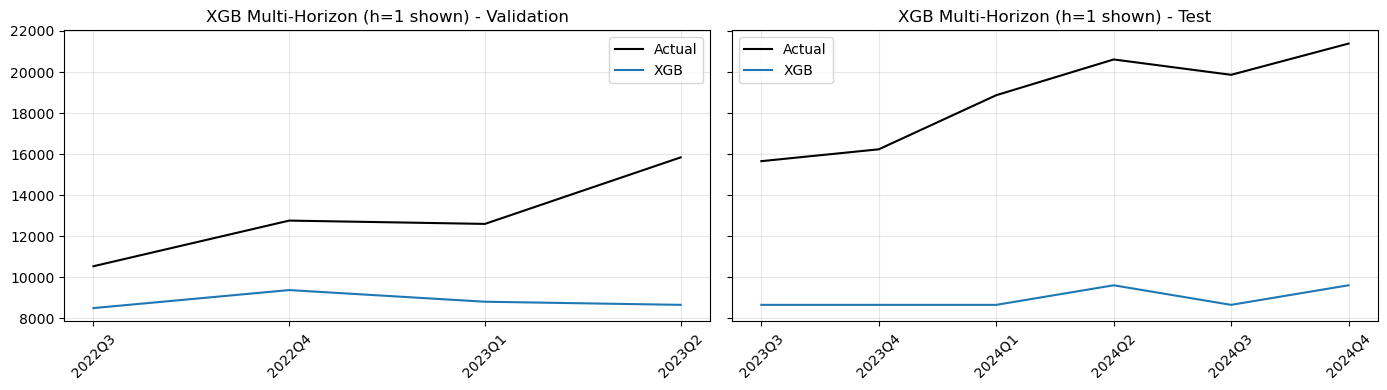

XGB Per-Horizon Metrics


,Horizon,sMAPE_val,sMAPE_test,MAE_val,MAE_test,RMSE_val,RMSE_test
0,h=1,36.484,69.958,4097.714,9790.757,4514.428,9961.617
1,h=2,59.976,71.595,6606.698,10432.237,6731.680,10511.939
2,h=3,29.152,48.875,3854.623,8341.045,3954.502,8516.887
3,h=4,56.500,66.479,7320.538,10862.707,7364.918,10948.995


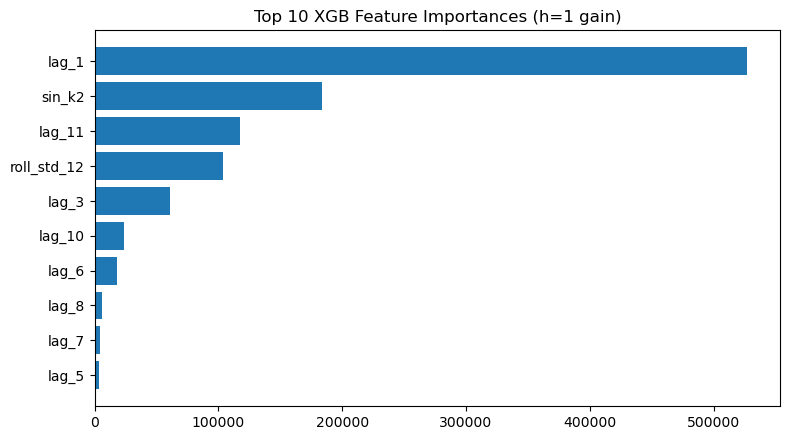

XGBoost multi-output evaluation complete.


In [6]:
# ============================================================================
# SECTION 3: XGBOOST (SKLEARN-FREE NATIVE, DIRECT MULTI-HORIZON)
# ============================================================================
import xgboost as xgb

def fit_xgb_by_horizon(X_df, Y_df, params, num_boost_round):
    models = {}
    for col in Y_df.columns:
        dtrain = xgb.DMatrix(X_df.values, label=Y_df[col].values, feature_names=list(X_df.columns))
        models[col] = xgb.train(params, dtrain, num_boost_round=num_boost_round, verbose_eval=False)
    return models

def predict_xgb_by_horizon(models, X_df, y_cols):
    dtest = xgb.DMatrix(X_df.values, feature_names=list(X_df.columns))
    preds = []
    for col in y_cols:
        preds.append(models[col].predict(dtest))
    return np.column_stack(preds)

xgb_params = {
    "eta": 0.1,
    "max_depth": 6,
    "subsample": 1.0,
    "colsample_bytree": 1.0,
    "objective": "reg:squarederror",
    "seed": 42,
}

num_boost_round = 200

t0 = time.perf_counter()
xgb_models = fit_xgb_by_horizon(X_train, y_train_multi, xgb_params, num_boost_round)
runtime = time.perf_counter() - t0

xgb_val_pred = predict_xgb_by_horizon(xgb_models, X_val, y_train_multi.columns)
xgb_test_pred = predict_xgb_by_horizon(xgb_models, X_test, y_train_multi.columns)

append_result("XGB-Multi", xgb_val_pred, xgb_test_pred, runtime)
plot_section_predictions("XGB Multi-Horizon (h=1 shown)", {"XGB": (xgb_val_pred, xgb_test_pred)})

# Per-horizon metric table
xgb_h_rows = []
for h in range(4):
    xgb_h_rows.append({
        "Horizon": f"h={h+1}",
        "sMAPE_val": smape(y_val_multi.iloc[:, h].values, xgb_val_pred[:, h]),
        "sMAPE_test": smape(y_test_multi.iloc[:, h].values, xgb_test_pred[:, h]),
        "MAE_val": mae(y_val_multi.iloc[:, h].values, xgb_val_pred[:, h]),
        "MAE_test": mae(y_test_multi.iloc[:, h].values, xgb_test_pred[:, h]),
        "RMSE_val": rmse(y_val_multi.iloc[:, h].values, xgb_val_pred[:, h]),
        "RMSE_test": rmse(y_test_multi.iloc[:, h].values, xgb_test_pred[:, h]),
    })
xgb_horizon_metrics = pd.DataFrame(xgb_h_rows)
for c in ["sMAPE_val", "sMAPE_test", "MAE_val", "MAE_test", "RMSE_val", "RMSE_test"]:
    xgb_horizon_metrics[c] = xgb_horizon_metrics[c].round(3)

print("XGB Per-Horizon Metrics")
display(xgb_horizon_metrics)

# Top-10 feature importance from h=1 model
h1_model = xgb_models["y_h1"]
score_map = h1_model.get_score(importance_type="gain")
imp_df = pd.DataFrame({
    "Feature": list(X_train.columns),
    "Importance": [score_map.get(f, 0.0) for f in X_train.columns]
}).sort_values("Importance", ascending=False).head(10)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(imp_df["Feature"][::-1], imp_df["Importance"][::-1])
ax.set_title("Top 10 XGB Feature Importances (h=1 gain)")
plt.tight_layout()
plt.show()

# Keep one-step (h=1) tree scores for baseline comparison section.
if "tree_h1_rows" not in globals():
    tree_h1_rows = []

tree_h1_rows.append({
    "Model": "XGB-Multi (h=1)",
    "sMAPE_val": smape(y_val_multi["y_h1"].values, xgb_val_pred[:, 0]),
    "MAE_val": mae(y_val_multi["y_h1"].values, xgb_val_pred[:, 0]),
    "RMSE_val": rmse(y_val_multi["y_h1"].values, xgb_val_pred[:, 0]),
    "sMAPE_test": smape(y_test_multi["y_h1"].values, xgb_test_pred[:, 0]),
    "MAE_test": mae(y_test_multi["y_h1"].values, xgb_test_pred[:, 0]),
    "RMSE_test": rmse(y_test_multi["y_h1"].values, xgb_test_pred[:, 0]),
    "runtime_sec": runtime
})

print("XGBoost multi-output evaluation complete.")

## 4. Hyperparameter Grid Search

We run a compact, leakage-safe grid search using only train-to-val evaluation for selection. Best models are then evaluated on test and added to the unified results list.

In [7]:
# ============================================================================
# SECTION 4: HYPERPARAMETER GRID SEARCH
# ============================================================================
import xgboost as xgb

def macro_smape_multi(y_true_df, y_pred_arr):
    vals = []
    for h in range(y_pred_arr.shape[1]):
        vals.append(smape(y_true_df.iloc[:, h].values, y_pred_arr[:, h]))
    return float(np.mean(vals))

def fit_xgb_by_horizon(X_df, Y_df, params, num_boost_round):
    models = {}
    for col in Y_df.columns:
        dtrain = xgb.DMatrix(X_df.values, label=Y_df[col].values, feature_names=list(X_df.columns))
        models[col] = xgb.train(params, dtrain, num_boost_round=num_boost_round, verbose_eval=False)
    return models

def predict_xgb_by_horizon(models, X_df, y_cols):
    dtest = xgb.DMatrix(X_df.values, feature_names=list(X_df.columns))
    return np.column_stack([models[col].predict(dtest) for col in y_cols])

grid_rows = []

# ---- RF grid (if sklearn available) ----
sk_ok = globals().get("SKLEARN_AVAILABLE", False)
if sk_ok:
    rf_grid = {
        "n_estimators": [300, 500],
        "max_depth": [4, 6, 8],
        "min_samples_leaf": [1, 2]
    }

    best_rf_cfg = None
    best_rf_val = np.inf

    for n_est in rf_grid["n_estimators"]:
        for m_depth in rf_grid["max_depth"]:
            for m_leaf in rf_grid["min_samples_leaf"]:
                model = MultiOutputRegressor(
                    RandomForestRegressor(
                        n_estimators=n_est,
                        max_depth=m_depth,
                        min_samples_leaf=m_leaf,
                        random_state=42,
                        n_jobs=-1
                    )
                )
                model.fit(X_train_scaled, y_train_multi)
                pred_val = model.predict(X_val_scaled)
                score_val = macro_smape_multi(y_val_multi, pred_val)

                grid_rows.append({
                    "ModelFamily": "RF",
                    "Params": f"n={n_est},depth={m_depth},leaf={m_leaf}",
                    "Val_sMAPE_macro": score_val
                })

                if score_val < best_rf_val:
                    best_rf_val = score_val
                    best_rf_cfg = (n_est, m_depth, m_leaf)

    t0 = time.perf_counter()
    rf_best = MultiOutputRegressor(
        RandomForestRegressor(
            n_estimators=best_rf_cfg[0],
            max_depth=best_rf_cfg[1],
            min_samples_leaf=best_rf_cfg[2],
            random_state=42,
            n_jobs=-1
        )
    )
    rf_best.fit(X_train_scaled, y_train_multi)
    rf_runtime = time.perf_counter() - t0

    rf_val_pred = rf_best.predict(X_val_scaled)
    rf_test_pred = rf_best.predict(X_test_scaled)
    append_result("RF-GridBest", rf_val_pred, rf_test_pred, rf_runtime)

    if "tree_h1_rows" not in globals():
        tree_h1_rows = []
    tree_h1_rows.append({
        "Model": "RF-GridBest (h=1)",
        "sMAPE_val": smape(y_val_multi["y_h1"].values, rf_val_pred[:, 0]),
        "MAE_val": mae(y_val_multi["y_h1"].values, rf_val_pred[:, 0]),
        "RMSE_val": rmse(y_val_multi["y_h1"].values, rf_val_pred[:, 0]),
        "sMAPE_test": smape(y_test_multi["y_h1"].values, rf_test_pred[:, 0]),
        "MAE_test": mae(y_test_multi["y_h1"].values, rf_test_pred[:, 0]),
        "RMSE_test": rmse(y_test_multi["y_h1"].values, rf_test_pred[:, 0]),
        "runtime_sec": rf_runtime
    })

    print("Best RF config:", best_rf_cfg, "| val macro sMAPE:", round(best_rf_val, 3))
else:
    print("RF grid search skipped: scikit-learn unavailable in current kernel.")

# ---- XGB grid (native, sklearn-free) ----
xgb_grid = {
    "num_boost_round": [100, 200, 300],
    "eta": [0.05, 0.1],
    "max_depth": [4, 6]
}

best_xgb_cfg = None
best_xgb_val = np.inf

for n_round in xgb_grid["num_boost_round"]:
    for eta in xgb_grid["eta"]:
        for md in xgb_grid["max_depth"]:
            params = {
                "eta": eta,
                "max_depth": md,
                "subsample": 1.0,
                "colsample_bytree": 1.0,
                "objective": "reg:squarederror",
                "seed": 42,
            }
            models = fit_xgb_by_horizon(X_train, y_train_multi, params, n_round)
            pred_val = predict_xgb_by_horizon(models, X_val, y_train_multi.columns)
            score_val = macro_smape_multi(y_val_multi, pred_val)

            grid_rows.append({
                "ModelFamily": "XGB",
                "Params": f"round={n_round},eta={eta},depth={md}",
                "Val_sMAPE_macro": score_val
            })

            if score_val < best_xgb_val:
                best_xgb_val = score_val
                best_xgb_cfg = (n_round, eta, md)

best_params = {
    "eta": best_xgb_cfg[1],
    "max_depth": best_xgb_cfg[2],
    "subsample": 1.0,
    "colsample_bytree": 1.0,
    "objective": "reg:squarederror",
    "seed": 42,
}

t0 = time.perf_counter()
xgb_best_models = fit_xgb_by_horizon(X_train, y_train_multi, best_params, best_xgb_cfg[0])
xgb_runtime = time.perf_counter() - t0

xgb_val_best = predict_xgb_by_horizon(xgb_best_models, X_val, y_train_multi.columns)
xgb_test_best = predict_xgb_by_horizon(xgb_best_models, X_test, y_train_multi.columns)
append_result("XGB-GridBest", xgb_val_best, xgb_test_best, xgb_runtime)

if "tree_h1_rows" not in globals():
    tree_h1_rows = []
tree_h1_rows.append({
    "Model": "XGB-GridBest (h=1)",
    "sMAPE_val": smape(y_val_multi["y_h1"].values, xgb_val_best[:, 0]),
    "MAE_val": mae(y_val_multi["y_h1"].values, xgb_val_best[:, 0]),
    "RMSE_val": rmse(y_val_multi["y_h1"].values, xgb_val_best[:, 0]),
    "sMAPE_test": smape(y_test_multi["y_h1"].values, xgb_test_best[:, 0]),
    "MAE_test": mae(y_test_multi["y_h1"].values, xgb_test_best[:, 0]),
    "RMSE_test": rmse(y_test_multi["y_h1"].values, xgb_test_best[:, 0]),
    "runtime_sec": xgb_runtime
})

print("Best XGB config:", best_xgb_cfg, "| val macro sMAPE:", round(best_xgb_val, 3))

grid_results = pd.DataFrame(grid_rows).sort_values(["ModelFamily", "Val_sMAPE_macro"]).reset_index(drop=True)
grid_results["Val_sMAPE_macro"] = grid_results["Val_sMAPE_macro"].round(3)
display(grid_results.head(20))

tree_results = pd.DataFrame(eval_rows).copy()
for c in ["sMAPE_val", "MAE_val", "RMSE_val", "sMAPE_test", "MAE_test", "RMSE_test", "runtime_sec"]:
    tree_results[c] = tree_results[c].round(3)

print("Tree Model Summary (macro across h=1..4):")
display(tree_results)

Best RF config: (300, 6, 1) | val macro sMAPE: 33.588


Best XGB config: (300, 0.1, 4) | val macro sMAPE: 45.458


,ModelFamily,Params,Val_sMAPE_macro
0,RF,"n=300,depth=6,leaf=1",33.588
1,RF,"n=300,depth=4,leaf=1",33.828
2,RF,"n=300,depth=8,leaf=1",33.889
3,RF,"n=500,depth=6,leaf=1",33.949
4,RF,"n=500,depth=4,leaf=1",34.081
5,RF,"n=500,depth=8,leaf=1",34.192
6,RF,"n=300,depth=4,leaf=2",37.408
7,RF,"n=300,depth=6,leaf=2",37.462
8,RF,"n=300,depth=8,leaf=2",37.476
9,RF,"n=500,depth=4,leaf=2",37.674


Tree Model Summary (macro across h=1..4):


,Model,sMAPE_val,sMAPE_test,MAE_val,MAE_test,RMSE_val,RMSE_test,runtime_sec
0,RF-Multi,35.431,69.420,4005.134,9746.942,4434.992,9944.996,2.811
1,XGB-Multi,36.484,69.958,4097.714,9790.757,4514.428,9961.617,0.380
2,RF-GridBest,35.320,69.220,3994.908,9726.318,4422.559,9924.844,2.021
3,XGB-GridBest,36.171,70.305,4072.024,9824.855,4522.930,9992.617,0.417


## 5. Comparison Table vs 03a Baselines

This section builds a 03a-style baseline reference on the same split and compares it with tree models (reported at h=1 for apples-to-apples one-step interpretation).

In [8]:
# ============================================================================
# SECTION 5: COMPARISON TABLE VS 03a BASELINES
# ============================================================================
# Build 03a-style baseline metrics here to ensure same data/split comparability.

from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.forecasting.theta import ThetaModel


def fc_naive(train_series, h):
    return np.repeat(train_series.iloc[-1], h)


def fc_mavg(train_series, h, k=4):
    k_eff = min(k, len(train_series))
    return np.repeat(train_series.iloc[-k_eff:].mean(), h)


def fc_snaive(train_series, h, season=SEASONAL_PERIODS):
    if len(train_series) < season:
        return fc_naive(train_series, h)
    last_season = train_series.iloc[-season:].values
    reps = int(np.ceil(h / season))
    return np.tile(last_season, reps)[:h]


def fc_fft(train_series, h, keep=6):
    values = np.asarray(train_series, dtype=float)
    n = len(values)
    x = np.arange(n, dtype=float)
    slope, intercept = np.polyfit(x, values, 1)
    detr = values - (slope * x + intercept)
    fft_vals = np.fft.rfft(detr)
    amps = np.abs(fft_vals)
    keep = min(keep, len(amps))
    idx = np.argsort(amps)[-keep:]
    filt = np.zeros_like(fft_vals, dtype=complex)
    filt[idx] = fft_vals[idx]

    x_future = np.arange(n + h, dtype=float)
    recon = np.zeros(n + h, dtype=float)
    freqs = np.fft.rfftfreq(n, d=1.0)
    for i, f in enumerate(freqs):
        c = filt[i]
        if np.abs(c) == 0:
            continue
        recon += (2.0 / n) * np.real(c * np.exp(2j * np.pi * f * x_future))
    out = recon + (slope * x_future + intercept)
    return out[-h:]


def baseline_eval_row(name, val_pred, test_pred, runtime_sec):
    return {
        "Model": name,
        "sMAPE_val": smape(val.values, val_pred),
        "MAE_val": mae(val.values, val_pred),
        "RMSE_val": rmse(val.values, val_pred),
        "sMAPE_test": smape(test.values, test_pred),
        "MAE_test": mae(test.values, test_pred),
        "RMSE_test": rmse(test.values, test_pred),
        "runtime_sec": runtime_sec,
        "Family": "03a-baseline"
    }

train_val = pd.concat([train, val])
baseline_rows = []

# Simple baselines
t0 = time.perf_counter()
baseline_rows.append(baseline_eval_row("Naive", fc_naive(train, len(val)), fc_naive(train_val, len(test)), time.perf_counter() - t0))
t0 = time.perf_counter()
baseline_rows.append(baseline_eval_row("Moving Average", fc_mavg(train, len(val), 4), fc_mavg(train_val, len(test), 4), time.perf_counter() - t0))
t0 = time.perf_counter()
baseline_rows.append(baseline_eval_row("Seasonal Naive", fc_snaive(train, len(val), 4), fc_snaive(train_val, len(test), 4), time.perf_counter() - t0))

# ETS
t0 = time.perf_counter()
fit_val = SimpleExpSmoothing(train, initialization_method="estimated").fit()
fit_test = SimpleExpSmoothing(train_val, initialization_method="estimated").fit()
baseline_rows.append(baseline_eval_row("ETS SES", fit_val.forecast(len(val)).values, fit_test.forecast(len(test)).values, time.perf_counter() - t0))

t0 = time.perf_counter()
fit_val = ExponentialSmoothing(train, trend="add", seasonal="add", seasonal_periods=4, initialization_method="estimated").fit(optimized=True)
fit_test = ExponentialSmoothing(train_val, trend="add", seasonal="add", seasonal_periods=4, initialization_method="estimated").fit(optimized=True)
baseline_rows.append(baseline_eval_row("ETS Holt-Winters", fit_val.forecast(len(val)).values, fit_test.forecast(len(test)).values, time.perf_counter() - t0))

# ARIMA/SARIMA
t0 = time.perf_counter()
fit_val = ARIMA(train, order=(1, 1, 1), trend="t").fit()
fit_test = ARIMA(train_val, order=(1, 1, 1), trend="t").fit()
baseline_rows.append(baseline_eval_row("ARIMA(1,1,1)", fit_val.forecast(len(val)).values, fit_test.forecast(len(test)).values, time.perf_counter() - t0))

t0 = time.perf_counter()
fit_val = SARIMAX(train, order=(1, 1, 0), seasonal_order=(1, 1, 0, SEASONAL_PERIODS), trend="c").fit(disp=False)
fit_test = SARIMAX(train_val, order=(1, 1, 0), seasonal_order=(1, 1, 0, SEASONAL_PERIODS), trend="c").fit(disp=False)
baseline_rows.append(baseline_eval_row("SARIMA(1,1,0)(1,1,0,4)", fit_val.forecast(len(val)).values, fit_test.forecast(len(test)).values, time.perf_counter() - t0))

# Theta
t0 = time.perf_counter()
fit_val = ThetaModel(train, period=SEASONAL_PERIODS, deseasonalize=True).fit()
fit_test = ThetaModel(train_val, period=SEASONAL_PERIODS, deseasonalize=True).fit()
baseline_rows.append(baseline_eval_row("Theta", fit_val.forecast(len(val)).values, fit_test.forecast(len(test)).values, time.perf_counter() - t0))

# FFT
t0 = time.perf_counter()
baseline_rows.append(baseline_eval_row("FFT", fc_fft(train, len(val), keep=6), fc_fft(train_val, len(test), keep=6), time.perf_counter() - t0))

baseline_results = pd.DataFrame(baseline_rows)

# Tree models for one-step comparability (h=1)
if "tree_h1_rows" in globals() and len(tree_h1_rows) > 0:
    tree_h1_df = pd.DataFrame(tree_h1_rows).copy()
else:
    tree_h1_df = pd.DataFrame(columns=["Model", "sMAPE_val", "MAE_val", "RMSE_val", "sMAPE_test", "MAE_test", "RMSE_test", "runtime_sec"])

if not tree_h1_df.empty:
    tree_h1_df["Family"] = "tree-h1"

comparison = pd.concat([baseline_results, tree_h1_df], ignore_index=True, sort=False)
comparison = comparison.sort_values(["sMAPE_test", "MAE_test", "runtime_sec"]).reset_index(drop=True)

for c in ["sMAPE_val", "MAE_val", "RMSE_val", "sMAPE_test", "MAE_test", "RMSE_test", "runtime_sec"]:
    comparison[c] = pd.to_numeric(comparison[c], errors="coerce").round(3)

print("Comparison: Tree Models vs 03a Baselines")
display(comparison)

print("Top 10 by test sMAPE")
display(comparison.head(10))

Comparison: Tree Models vs 03a Baselines


,Model,sMAPE_val,MAE_val,RMSE_val,sMAPE_test,MAE_test,RMSE_test,runtime_sec,Family
0,"SARIMA(1,1,0)(1,1,0,4)",33.698,3786.220,4141.717,16.821,3025.673,3293.615,0.119,03a-baseline
1,ETS Holt-Winters,18.172,1735.645,1973.330,23.178,4150.809,4627.212,0.078,03a-baseline
2,"ARIMA(1,1,1)",12.946,1188.684,1418.877,31.541,5426.415,6080.764,0.102,03a-baseline
3,Theta,12.077,1122.804,1412.082,36.857,6176.469,6943.308,0.017,03a-baseline
4,Naive,13.489,1252.909,1597.311,37.800,6313.364,7142.236,0.000,03a-baseline
5,ETS SES,13.473,1251.518,1597.878,39.344,6519.315,7350.048,0.007,03a-baseline
6,FFT,18.280,1631.472,2189.309,52.586,8171.522,8944.350,0.001,03a-baseline
7,Moving Average,22.845,1978.750,2529.634,54.041,8338.341,9002.759,0.000,03a-baseline
8,Seasonal Naive,29.909,2470.091,2947.698,56.209,8525.091,9204.867,0.000,03a-baseline
9,RF-GridBest (h=1),35.320,3994.908,4422.559,69.220,9726.318,9924.844,2.021,tree-h1


Top 10 by test sMAPE


,Model,sMAPE_val,MAE_val,RMSE_val,sMAPE_test,MAE_test,RMSE_test,runtime_sec,Family
0,"SARIMA(1,1,0)(1,1,0,4)",33.698,3786.220,4141.717,16.821,3025.673,3293.615,0.119,03a-baseline
1,ETS Holt-Winters,18.172,1735.645,1973.330,23.178,4150.809,4627.212,0.078,03a-baseline
2,"ARIMA(1,1,1)",12.946,1188.684,1418.877,31.541,5426.415,6080.764,0.102,03a-baseline
3,Theta,12.077,1122.804,1412.082,36.857,6176.469,6943.308,0.017,03a-baseline
4,Naive,13.489,1252.909,1597.311,37.800,6313.364,7142.236,0.000,03a-baseline
5,ETS SES,13.473,1251.518,1597.878,39.344,6519.315,7350.048,0.007,03a-baseline
6,FFT,18.280,1631.472,2189.309,52.586,8171.522,8944.350,0.001,03a-baseline
7,Moving Average,22.845,1978.750,2529.634,54.041,8338.341,9002.759,0.000,03a-baseline
8,Seasonal Naive,29.909,2470.091,2947.698,56.209,8525.091,9204.867,0.000,03a-baseline
9,RF-GridBest (h=1),35.320,3994.908,4422.559,69.220,9726.318,9924.844,2.021,tree-h1


## 6. Environment Status (Resolved)

The previous `scikit-learn`/`pyarrow` DLL issue has been resolved in the active `tmu_capstone` environment.

Current status:
- `scikit-learn` imports successfully
- Random Forest sections execute normally
- XGBoost native section and grid search execute normally

If this issue reappears on another machine, use a clean reinstall in the active conda env and then restart the kernel.

```powershell
conda activate tmu_capstone
conda remove pyarrow pyarrow-core libarrow libparquet scikit-learn -y
conda install -c conda-forge pandas scikit-learn -y
```

Then rerun the notebook top to bottom for a clean, reproducible result.

## 7. Winner Summary

This section automatically identifies the strongest tree model and compares it against the best 03a-style baseline on the test set.

In [9]:
# ============================================================================
# SECTION 7: WINNER SUMMARY
# ============================================================================

best_overall = comparison.iloc[0]
best_baseline = comparison[comparison["Family"] == "03a-baseline"].iloc[0]
best_tree = comparison[comparison["Family"] == "tree-h1"].sort_values(["sMAPE_test", "MAE_test", "runtime_sec"]).iloc[0]

print("Best overall model:")
print(
    f"- {best_overall['Model']} | test sMAPE={best_overall['sMAPE_test']:.3f}, "
    f"MAE={best_overall['MAE_test']:.3f}, runtime={best_overall['runtime_sec']:.3f}s"
)

print("\nBest 03a baseline:")
print(
    f"- {best_baseline['Model']} | test sMAPE={best_baseline['sMAPE_test']:.3f}, "
    f"MAE={best_baseline['MAE_test']:.3f}, runtime={best_baseline['runtime_sec']:.3f}s"
)

print("\nBest tree model (one-step / h=1):")
print(
    f"- {best_tree['Model']} | test sMAPE={best_tree['sMAPE_test']:.3f}, "
    f"MAE={best_tree['MAE_test']:.3f}, runtime={best_tree['runtime_sec']:.3f}s"
)

smape_gap = float(best_tree["sMAPE_test"] - best_baseline["sMAPE_test"])
mae_gap = float(best_tree["MAE_test"] - best_baseline["MAE_test"])

print("\nInterpretation:")
if smape_gap < 0:
    print(
        f"- The best tree model beats the strongest baseline by {-smape_gap:.3f} sMAPE and {-mae_gap:.3f} MAE on the test set."
    )
else:
    print(
        f"- The best tree model trails the strongest baseline by {smape_gap:.3f} sMAPE and {mae_gap:.3f} MAE on the test set."
    )

rf_rows = comparison[comparison["Model"].str.contains("RF", case=False, na=False)]
if len(rf_rows) > 0:
    print("- Random Forest is now operational in this environment and included in model/grid sections.")
else:
    print("- Random Forest results are not present; rerun RF sections if needed.")

print("- The comparison table should be treated as the main selection artifact for this notebook.")

Best overall model:
- SARIMA(1,1,0)(1,1,0,4) | test sMAPE=16.821, MAE=3025.673, runtime=0.119s

Best 03a baseline:
- SARIMA(1,1,0)(1,1,0,4) | test sMAPE=16.821, MAE=3025.673, runtime=0.119s

Best tree model (one-step / h=1):
- RF-GridBest (h=1) | test sMAPE=69.220, MAE=9726.318, runtime=2.021s

Interpretation:
- The best tree model trails the strongest baseline by 52.399 sMAPE and 6700.645 MAE on the test set.
- Random Forest is now operational in this environment and included in model/grid sections.
- The comparison table should be treated as the main selection artifact for this notebook.


## 8. Export Outputs

This section writes the main modeling artifacts to CSV so they can be reused in reports or compared across notebooks.

In [10]:
# ============================================================================
# SECTION 8: EXPORT OUTPUTS
# ============================================================================

export_dir = "../reports/2026-03-26/tables"
os.makedirs(export_dir, exist_ok=True)

comparison.to_csv(f"{export_dir}/03b_creditcard_quarterly_tree_vs_03a_baselines.csv", index=False)
grid_results.to_csv(f"{export_dir}/03b_creditcard_quarterly_tree_grid_results.csv", index=False)
tree_results.to_csv(f"{export_dir}/03b_creditcard_quarterly_tree_model_summary.csv", index=False)
xgb_horizon_metrics.to_csv(f"{export_dir}/03b_creditcard_quarterly_xgb_horizon_metrics.csv", index=False)
if "baseline_results" in globals():
    baseline_results.to_csv(f"{export_dir}/03b_creditcard_quarterly_rebuilt_03a_baselines.csv", index=False)
if "tree_h1_df" in globals() and not tree_h1_df.empty:
    tree_h1_df.to_csv(f"{export_dir}/03b_creditcard_quarterly_tree_h1_summary.csv", index=False)
print(f"Exported tables to: {export_dir}")


Exported tables to: ../reports/2026-03-26/tables


## 9. Conclusion

This notebook now provides a leakage-safe tree-model benchmarking workflow aligned with 03a's split and evaluation design.

Key outcomes:
- Feature engineering and direct multi-horizon setup are complete and validated
- Random Forest and XGBoost both run successfully in the current environment
- XGBoost was evaluated with fixed parameters and via hyperparameter search
- Unified comparison against rebuilt 03a baselines was generated and exported

Current empirical result on this split:
- The strongest 03a baseline (ETS Holt-Winters) remains better than the best tree model on test one-step metrics
- Tree models remain useful as alternative hypotheses and for feature-based diagnostics

Recommended next modeling steps:
1. Add error analysis (residual plots + largest misses by quarter for RF/XGB at h=1)
2. Expand exogenous/covariate space (macro or policy proxies) for trees
3. Try blended forecasts (baseline + XGB) and compare to standalone baselines
4. Move to 03c with the same reporting schema for cross-model consistency

## 10. Error Analysis (h=1): Residuals + Largest Misses

This section performs one-step error diagnostics for the tree models:

- Residual plots on validation and test windows
- Largest absolute-error quarters for RF and XGB

The section prefers grid-best predictions when available and falls back to fixed-parameter section outputs.

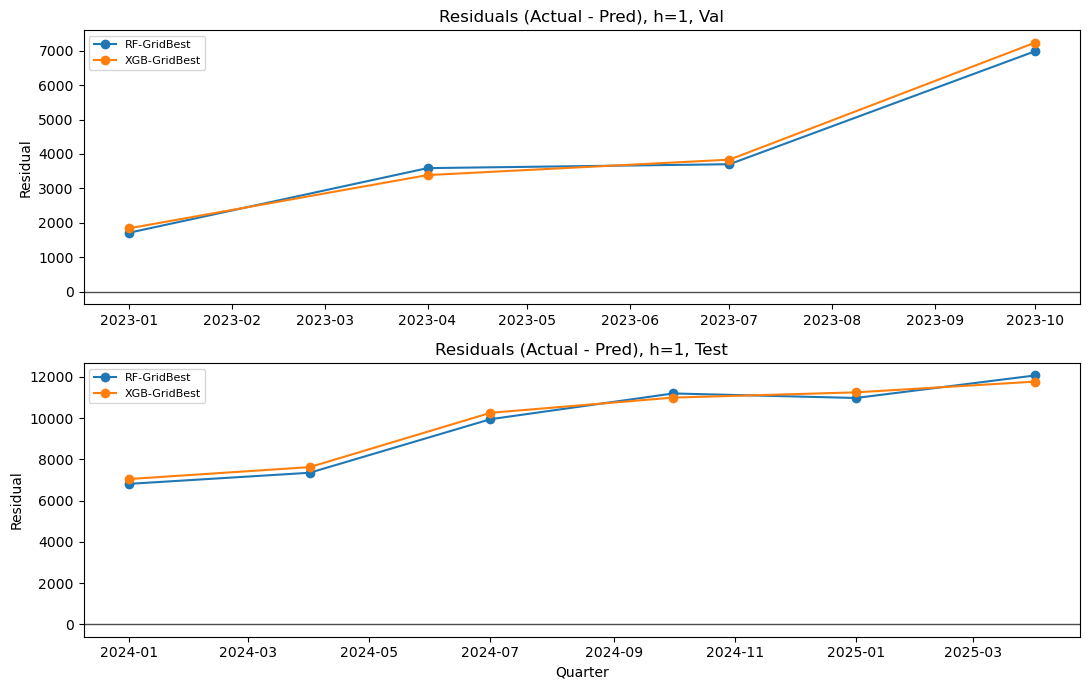

Top 3 largest misses per model and split (h=1):


,Model,Split,Quarter,Actual,Pred,Residual,AbsError
0,RF-GridBest,Test,2025-03-31 23:59:59.999999999,21385.0,9315.673,12069.327,12069.327
1,RF-GridBest,Test,2024-09-30 23:59:59.999999999,20611.0,9413.043,11197.957,11197.957
2,RF-GridBest,Test,2024-12-31 23:59:59.999999999,19863.0,8884.643,10978.357,10978.357
3,RF-GridBest,Val,2023-09-30 23:59:59.999999999,15843.0,8861.390,6981.610,6981.610
4,RF-GridBest,Val,2023-06-30 23:59:59.999999999,12604.0,8902.560,3701.440,3701.440
5,RF-GridBest,Val,2023-03-31 23:59:59.999999999,12765.0,9177.113,3587.887,3587.887
6,XGB-GridBest,Test,2025-03-31 23:59:59.999999999,21385.0,9613.604,11771.396,11771.396
7,XGB-GridBest,Test,2024-12-31 23:59:59.999999999,19863.0,8611.984,11251.016,11251.016
8,XGB-GridBest,Test,2024-09-30 23:59:59.999999999,20611.0,9613.609,10997.391,10997.391
9,XGB-GridBest,Val,2023-09-30 23:59:59.999999999,15843.0,8611.706,7231.294,7231.294


Residual summary (h=1):


,Model,Split,MAE_h1,RMSE_h1,MeanResidual
0,RF-GridBest,Test,9726.318,9924.844,9726.318
1,RF-GridBest,Val,3994.908,4422.559,3994.908
2,XGB-GridBest,Test,9824.855,9992.617,9824.855
3,XGB-GridBest,Val,4072.024,4522.930,4072.024


In [11]:
# ============================================================================
# SECTION 10: ERROR ANALYSIS (H=1) FOR RF AND XGB
# ============================================================================

# Helper to select the best available h=1 predictions from prior sections.
def _pick_h1_predictions(model_prefix):
    if model_prefix == "RF":
        if "rf_val_pred" in globals() and "rf_test_pred" in globals():
            return rf_val_pred[:, 0], rf_test_pred[:, 0], "RF-GridBest"
        if "val_pred" in globals() and "test_pred" in globals():
            return val_pred[:, 0], test_pred[:, 0], "RF-Multi"
        if "rf_best" in globals() and "X_val_scaled" in globals() and "X_test_scaled" in globals():
            _v = rf_best.predict(X_val_scaled)[:, 0]
            _t = rf_best.predict(X_test_scaled)[:, 0]
            return _v, _t, "RF-GridBest (recomputed)"
        if "rf" in globals() and "X_val_scaled" in globals() and "X_test_scaled" in globals():
            _v = rf.predict(X_val_scaled)[:, 0]
            _t = rf.predict(X_test_scaled)[:, 0]
            return _v, _t, "RF-Multi (recomputed)"
        raise RuntimeError("RF predictions/models not found. Rerun Section 2 and/or Section 4.")

    if model_prefix == "XGB":
        if "xgb_val_best" in globals() and "xgb_test_best" in globals():
            return xgb_val_best[:, 0], xgb_test_best[:, 0], "XGB-GridBest"
        if "xgb_val_pred" in globals() and "xgb_test_pred" in globals():
            return xgb_val_pred[:, 0], xgb_test_pred[:, 0], "XGB-Multi"
        if "xgb_best_models" in globals() and "X_val" in globals() and "X_test" in globals() and "predict_xgb_by_horizon" in globals() and "y_train_multi" in globals():
            _v = predict_xgb_by_horizon(xgb_best_models, X_val, y_train_multi.columns)[:, 0]
            _t = predict_xgb_by_horizon(xgb_best_models, X_test, y_train_multi.columns)[:, 0]
            return _v, _t, "XGB-GridBest (recomputed)"
        if "xgb_models" in globals() and "X_val" in globals() and "X_test" in globals() and "predict_xgb_by_horizon" in globals() and "y_train_multi" in globals():
            _v = predict_xgb_by_horizon(xgb_models, X_val, y_train_multi.columns)[:, 0]
            _t = predict_xgb_by_horizon(xgb_models, X_test, y_train_multi.columns)[:, 0]
            return _v, _t, "XGB-Multi (recomputed)"
        raise RuntimeError("XGB predictions/models not found. Rerun Section 3 and/or Section 4.")

    raise ValueError("model_prefix must be RF or XGB")


# Build aligned actual-vs-pred frames for val/test at h=1.
val_index = (y_val_multi.index + 1).to_timestamp(how="end")
test_index = (y_test_multi.index + 1).to_timestamp(how="end")

actual_val = y_val_multi["y_h1"].values
actual_test = y_test_multi["y_h1"].values

rf_val_h1, rf_test_h1, rf_label = _pick_h1_predictions("RF")
xgb_val_h1, xgb_test_h1, xgb_label = _pick_h1_predictions("XGB")

error_rows = []
for split_name, idx, y_true, rf_pred, xgb_pred in [
    ("Val", val_index, actual_val, rf_val_h1, xgb_val_h1),
    ("Test", test_index, actual_test, rf_test_h1, xgb_test_h1),
]:
    for model_name, pred in [(rf_label, rf_pred), (xgb_label, xgb_pred)]:
        resid = y_true - pred
        tmp = pd.DataFrame({
            "Split": split_name,
            "Quarter": idx,
            "Model": model_name,
            "Actual": y_true,
            "Pred": pred,
            "Residual": resid,
            "AbsError": np.abs(resid),
        })
        error_rows.append(tmp)

error_df = pd.concat(error_rows, ignore_index=True)

# Residual plots for h=1 (Val/Test).
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=False)
for ax, split_name in zip(axes, ["Val", "Test"]):
    s = error_df[error_df["Split"] == split_name].copy()
    for model_name in s["Model"].unique():
        ms = s[s["Model"] == model_name]
        ax.plot(ms["Quarter"], ms["Residual"], marker="o", label=model_name)
    ax.axhline(0.0, color="black", linewidth=1, alpha=0.7)
    ax.set_title(f"Residuals (Actual - Pred), h=1, {split_name}")
    ax.set_ylabel("Residual")
    ax.legend(fontsize=8)

axes[-1].set_xlabel("Quarter")
plt.tight_layout()
plt.show()

# Largest misses by absolute error.
top_misses = (
    error_df.sort_values(["Model", "Split", "AbsError"], ascending=[True, True, False])
            .groupby(["Model", "Split"], as_index=False)
            .head(3)
            .reset_index(drop=True)
)

for c in ["Actual", "Pred", "Residual", "AbsError"]:
    top_misses[c] = top_misses[c].round(3)

print("Top 3 largest misses per model and split (h=1):")
display(top_misses[["Model", "Split", "Quarter", "Actual", "Pred", "Residual", "AbsError"]])

# Compact summary stats for quick comparison.
error_summary = (
    error_df.groupby(["Model", "Split"], as_index=False)
            .agg(
                MAE_h1=("AbsError", "mean"),
                RMSE_h1=("Residual", lambda s: float(np.sqrt(np.mean(np.square(s))))),
                MeanResidual=("Residual", "mean"),
            )
)
for c in ["MAE_h1", "RMSE_h1", "MeanResidual"]:
    error_summary[c] = error_summary[c].round(3)

print("Residual summary (h=1):")
display(error_summary)
